# Graph Interpretation Bottleneck on a Hidden Automaton

This notebook builds the synthetic hidden-automaton benchmark for the graph interpretation bottleneck. It samples a hidden probabilistic finite-state automaton, generates observable symbol sequences, trains a tiny sequence transformer, trains the bottleneck graphicalizer on the resulting token embeddings, and visualizes the true automaton next to the learned graph.

The final figures are meant for visual diagnosis. Exact recovery is not guaranteed in a short notebook run, but the collapsed learned graph uses the hidden labels only after training so you can inspect whether learned prototype relations align with the latent automaton transitions.


In [1]:
from pathlib import Path
import runpy

BOOTSTRAP_CANDIDATES = (
    "notebooks/_bootstrap.py",
    "abstractgraph/notebooks/_bootstrap.py",
    "abstractgraph-ml/notebooks/_bootstrap.py",
    "abstractgraph-generative/notebooks/_bootstrap.py",
    "abstractgraph-graphicalizer/notebooks/_bootstrap.py",
)

_bootstrap_path = next(
    (
        candidate / relative
        for candidate in (Path.cwd(), *Path.cwd().parents)
        for relative in BOOTSTRAP_CANDIDATES
        if (candidate / relative).exists()
    ),
    None,
)
if _bootstrap_path is None:
    raise FileNotFoundError("Could not locate ecosystem notebooks/_bootstrap.py")

_bootstrap = runpy.run_path(str(_bootstrap_path))
repo_root = _bootstrap["repo_root"]
workspace_root = _bootstrap["workspace_root"]
repo_root


PosixPath('/Users/fabriziocosta/Resilio Sync/Sync/Projects/ACTIVE/abstractgraph-ecosystem/repos/abstractgraph-graphicalizer')

In [2]:
import math
from collections import Counter, defaultdict

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import torch

from abstractgraph_graphicalizer.bottleneck import (
    BottleneckGraphicalizer,
    evaluate_automaton_recovery,
    extract_sequence_embeddings,
    generate_automaton_sequences,
    sample_hidden_automaton,
    train_tiny_sequence_transformer,
)

plt.rcParams.update({
    "figure.figsize": (12, 5),
    "axes.spines.top": False,
    "axes.spines.right": False,
})

SEED = 7
np.random.seed(SEED)
torch.manual_seed(SEED)


/Users/fabriziocosta/miniconda3/envs/py311/lib/python3.11/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.5.0) or chardet (7.2.0)/charset_normalizer (3.4.3) doesn't match a supported version!
  warnings.warn(


## 1. Sample a Hidden Automaton

The model only observes emitted symbol sequences. Hidden states and transition probabilities are retained for evaluation and plotting.


In [3]:
automaton = sample_hidden_automaton(
    n_states=5,
    vocab_size=8,
    transition_concentration=0.18,
    emission_concentration=0.25,
    random_state=SEED,
)

data = generate_automaton_sequences(
    automaton,
    n_sequences=96,
    length=32,
    random_state=SEED + 1,
)

print("states:", automaton.n_states)
print("vocab size:", automaton.vocab_size)
print("sequences:", len(data["sequences"]))
print("first observed sequence:", data["sequences"][0].tolist())
print("first hidden path:", data["hidden_states"][0].tolist())


states: 5
vocab size: 8
sequences: 96
first observed sequence: [7, 6, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 7, 2, 2, 2, 3, 2, 3, 1, 7, 2, 2, 2, 3, 2, 2, 2, 2, 2]
first hidden path: [2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 3, 4, 2, 2, 2, 2, 2, 2, 3, 4, 2, 2, 2, 2, 2, 2, 2, 2, 2]


In [4]:
def transition_graph_from_automaton(automaton, threshold=0.04):
    graph = nx.DiGraph()
    for state in range(automaton.n_states):
        graph.add_node(state, label=f"s{state}")
    for src in range(automaton.n_states):
        for dst in range(automaton.n_states):
            prob = float(automaton.transition_probs[src, dst])
            if prob >= threshold:
                graph.add_edge(src, dst, probability=prob, weight=prob)
    return graph

true_graph = transition_graph_from_automaton(automaton, threshold=0.04)
true_graph.number_of_nodes(), true_graph.number_of_edges()


(5, 10)

## 2. Train the Tiny Sequence Transformer

The tiny transformer is trained with next-token prediction. Its token embeddings become the dense representation that the bottleneck graphicalizer must compress into a sparse graph.


In [5]:
sequence_encoder = train_tiny_sequence_transformer(
    data["sequences"],
    vocab_size=automaton.vocab_size,
    d_model=32,
    n_heads=4,
    num_layers=2,
    n_epochs=8,
    lr=2e-3,
    device="cpu",
)

embeddings = extract_sequence_embeddings(sequence_encoder, data["sequences"], device="cpu")
print(len(embeddings), embeddings[0].shape)


96 (32, 32)


## 3. Train the Bottleneck Graphicalizer

The graphicalizer receives only the transformer embeddings. The hidden state labels are not passed to training.


In [6]:
graphicalizer = BottleneckGraphicalizer(
    d_model=32,
    num_prototypes=12,
    use_encoder=False,
    n_epochs=18,
    lr=2e-3,
    output_graph="directed",
    active_only=True,
    top_k_edges=3,
    edge_threshold=0.35,
    gnn_layers=2,
    hidden_dim=48,
    node_mask_ratio=0.2,
    token_mask_ratio=0.2,
    lambda_token=0.2,
    lambda_sparse=0.02,
    lambda_binary=0.01,
    lambda_entropy=0.01,
    device="cpu",
)

learned_graphs = graphicalizer.fit_transform(embeddings)
learned_graph = learned_graphs[0]
print("learned graphs:", len(learned_graphs))
print("first learned graph nodes/edges:", learned_graph.number_of_nodes(), learned_graph.number_of_edges())


learned graphs: 96
first learned graph nodes/edges: 12 36


## 4. Quantitative Diagnostics

These metrics use the hidden state trace only after training. They are useful for comparing runs and hyperparameters, but the visual graph comparison below is often more informative.


In [7]:
learned_assignments = [graph.graph["token_to_nodes"] for graph in learned_graphs]
metrics = evaluate_automaton_recovery(
    learned_assignments,
    data["hidden_states"],
    learned_graph=learned_graph,
    automaton=automaton,
    transition_threshold=0.04,
)
metrics


{'clustering_accuracy': 0.5325520833333334,
 'purity': 0.7532552083333334,
 'n_learned_nodes': 12.0,
 'n_true_states': 5.0,
 'edge_precision': 0.6666666666666666,
 'edge_recall': 0.2}

In [8]:
def prototype_state_counts(graphs, hidden_states):
    counts = defaultdict(Counter)
    for graph, states in zip(graphs, hidden_states):
        token_to_nodes = graph.graph["token_to_nodes"]
        for token_idx, proto in enumerate(token_to_nodes):
            counts[proto][int(states[token_idx])] += 1
    return counts

def majority_state_map(counts):
    mapping = {}
    for proto, counter in counts.items():
        if counter:
            mapping[int(proto)] = int(counter.most_common(1)[0][0])
    return mapping

proto_counts = prototype_state_counts(learned_graphs, data["hidden_states"])
proto_to_state = majority_state_map(proto_counts)
proto_to_state


{8: 2, 9: 2, 5: 2, 7: 2, 11: 2, 2: 2, 6: 2, 3: 2, 1: 2, 0: 3, 10: 1, 4: 2}

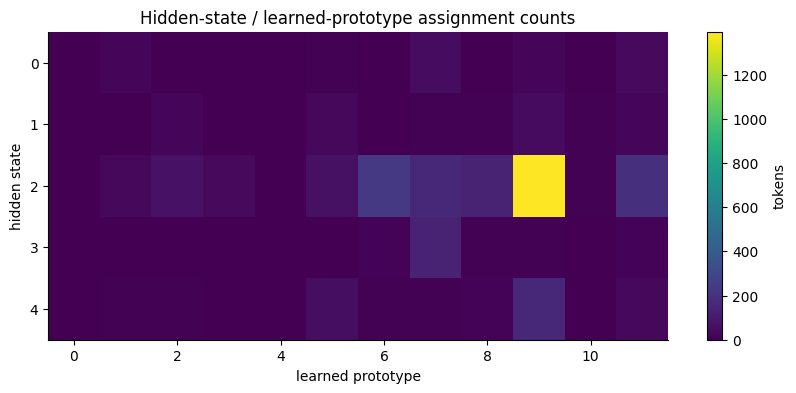

In [9]:
confusion = np.zeros((automaton.n_states, graphicalizer.num_prototypes), dtype=int)
for graph, states in zip(learned_graphs, data["hidden_states"]):
    for proto, state in zip(graph.graph["token_to_nodes"], states):
        confusion[int(state), int(proto)] += 1

fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(confusion, aspect="auto", cmap="viridis")
ax.set_title("Hidden-state / learned-prototype assignment counts")
ax.set_xlabel("learned prototype")
ax.set_ylabel("hidden state")
fig.colorbar(im, ax=ax, label="tokens")
plt.show()


## 5. Visualize True and Learned Graphs

The left plot is the hidden automaton. The right plot is the learned prototype graph from one sequence, with each prototype colored by its majority hidden state across the dataset. Edge widths are probabilities.


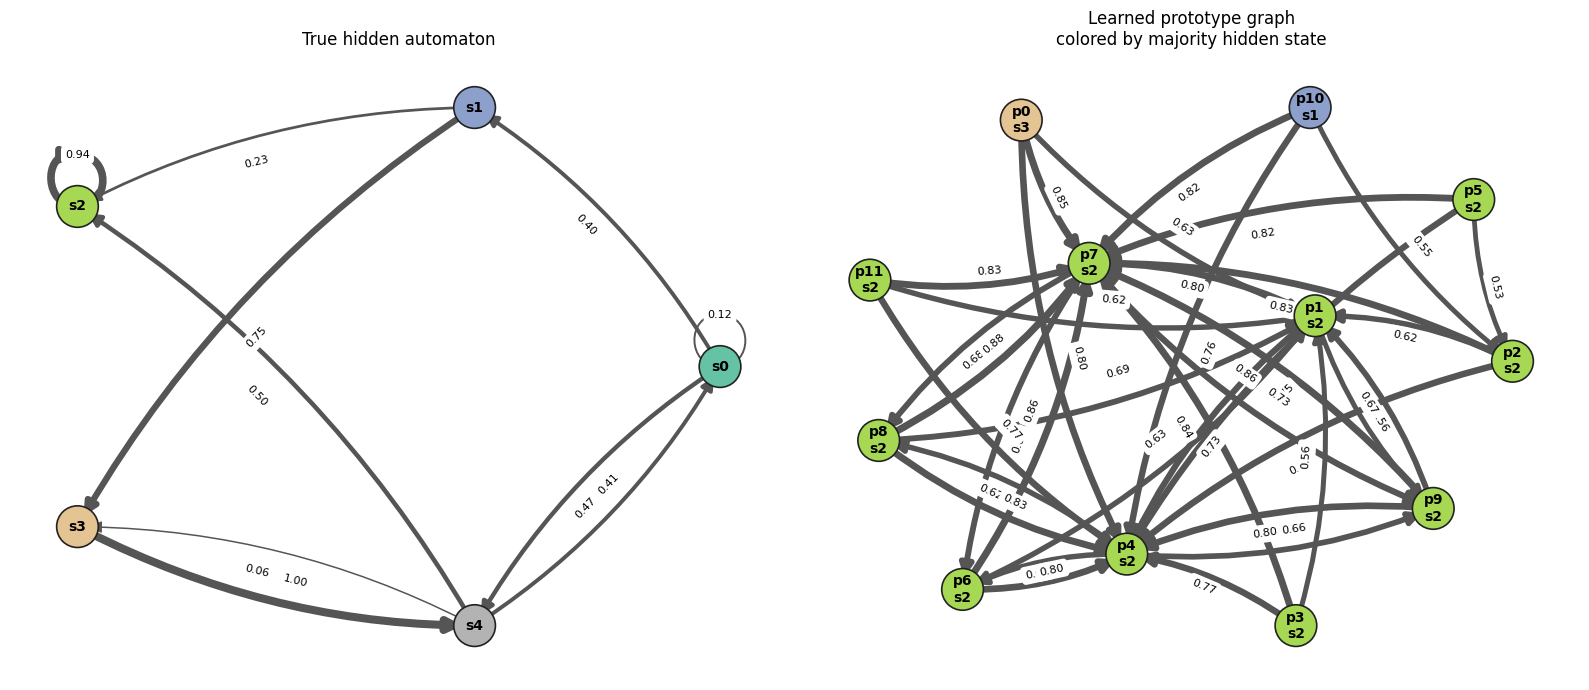

In [10]:
state_palette = plt.cm.Set2(np.linspace(0, 1, automaton.n_states))
state_colors = {state: state_palette[state] for state in range(automaton.n_states)}

def draw_weighted_digraph(ax, graph, pos, title, node_state=None, node_labels=None, edge_key="probability"):
    node_colors = []
    for node in graph.nodes():
        state = node_state[node] if node_state is not None and node in node_state else node
        node_colors.append(state_colors.get(int(state), (0.75, 0.75, 0.75, 1.0)))

    widths = [0.8 + 5.0 * float(graph.edges[e].get(edge_key, graph.edges[e].get("weight", 0.1))) for e in graph.edges()]
    nx.draw_networkx_nodes(graph, pos, node_color=node_colors, node_size=900, edgecolors="#222222", linewidths=1.2, ax=ax)
    nx.draw_networkx_edges(
        graph,
        pos,
        width=widths,
        edge_color="#555555",
        arrows=True,
        arrowsize=18,
        connectionstyle="arc3,rad=0.12",
        ax=ax,
    )
    labels = node_labels or {node: str(node) for node in graph.nodes()}
    nx.draw_networkx_labels(graph, pos, labels=labels, font_size=10, font_weight="bold", ax=ax)
    edge_labels = {
        edge: f"{float(graph.edges[edge].get(edge_key, graph.edges[edge].get('weight', 0.0))):.2f}"
        for edge in graph.edges()
    }
    nx.draw_networkx_edge_labels(graph, pos, edge_labels=edge_labels, font_size=8, ax=ax, label_pos=0.55)
    ax.set_title(title)
    ax.set_axis_off()

true_pos = nx.circular_layout(true_graph)

learned_proto_state = {}
learned_labels = {}
for node, attrs in learned_graph.nodes(data=True):
    proto = int(attrs["prototype_id"])
    learned_proto_state[node] = proto_to_state.get(proto, -1)
    learned_labels[node] = f"p{proto}\ns{learned_proto_state[node]}"

learned_pos = nx.spring_layout(learned_graph, seed=SEED, k=1.2)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
draw_weighted_digraph(
    axes[0],
    true_graph,
    true_pos,
    "True hidden automaton",
    node_state={node: node for node in true_graph.nodes()},
    node_labels={node: f"s{node}" for node in true_graph.nodes()},
)
draw_weighted_digraph(
    axes[1],
    learned_graph,
    learned_pos,
    "Learned prototype graph\ncolored by majority hidden state",
    node_state=learned_proto_state,
    node_labels=learned_labels,
)
plt.tight_layout()
plt.show()


## 6. Collapse Learned Prototypes Back to Inferred States

This view aggregates learned prototype edges by the majority hidden state assigned to each prototype. It uses labels only for post-hoc inspection and should be visually comparable to the true automaton.


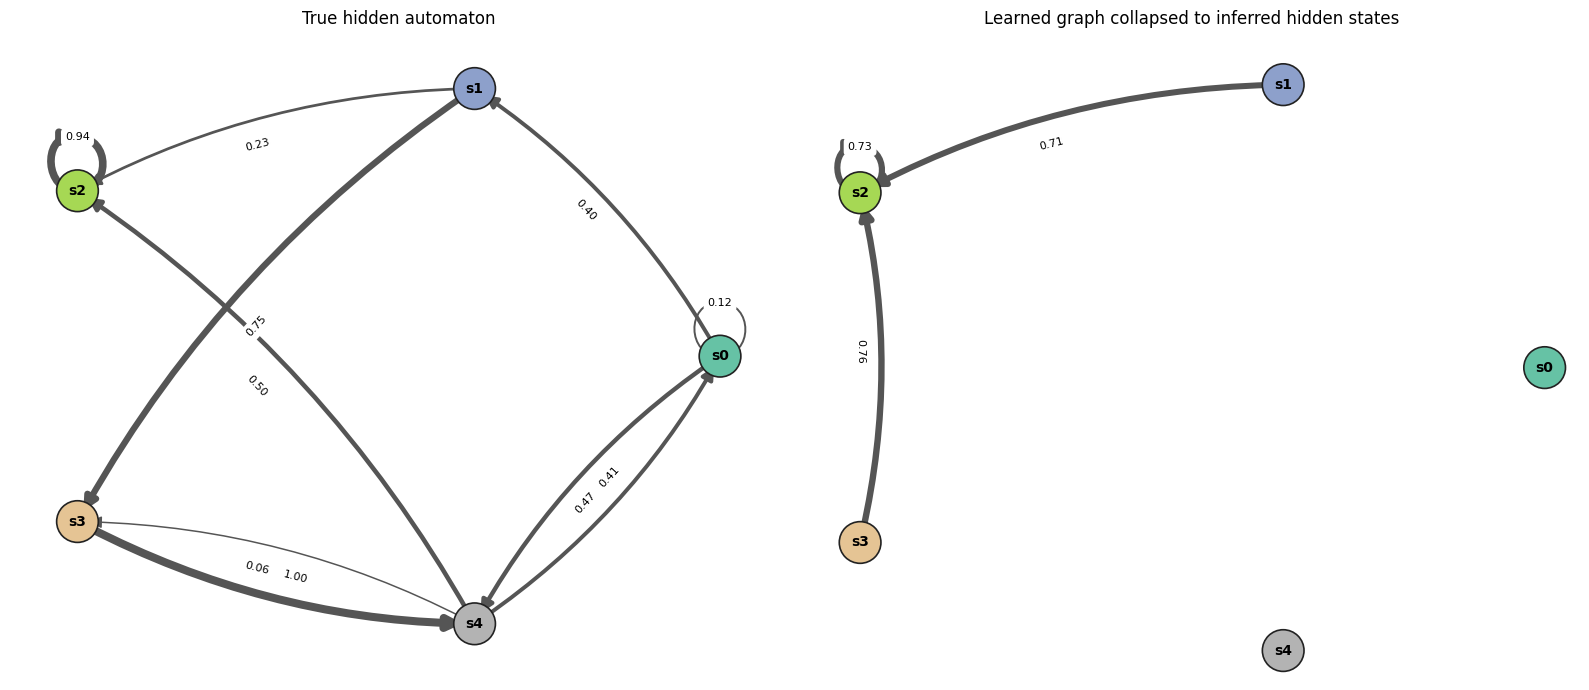

In [11]:
def collapse_learned_graph_to_states(graph, proto_to_state, n_states):
    collapsed = nx.DiGraph()
    for state in range(n_states):
        collapsed.add_node(state, label=f"s{state}")
    edge_weights = defaultdict(float)
    edge_counts = defaultdict(int)
    for u, v, attrs in graph.edges(data=True):
        src_proto = int(graph.nodes[u]["prototype_id"])
        dst_proto = int(graph.nodes[v]["prototype_id"])
        if src_proto not in proto_to_state or dst_proto not in proto_to_state:
            continue
        src_state = proto_to_state[src_proto]
        dst_state = proto_to_state[dst_proto]
        edge_weights[(src_state, dst_state)] += float(attrs.get("probability", attrs.get("weight", 0.0)))
        edge_counts[(src_state, dst_state)] += 1
    for edge, total in edge_weights.items():
        collapsed.add_edge(edge[0], edge[1], probability=total / edge_counts[edge], weight=total / edge_counts[edge])
    return collapsed

collapsed_graph = collapse_learned_graph_to_states(learned_graph, proto_to_state, automaton.n_states)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
draw_weighted_digraph(
    axes[0],
    true_graph,
    true_pos,
    "True hidden automaton",
    node_state={node: node for node in true_graph.nodes()},
    node_labels={node: f"s{node}" for node in true_graph.nodes()},
)
draw_weighted_digraph(
    axes[1],
    collapsed_graph,
    true_pos,
    "Learned graph collapsed to inferred hidden states",
    node_state={node: node for node in collapsed_graph.nodes()},
    node_labels={node: f"s{node}" for node in collapsed_graph.nodes()},
)
plt.tight_layout()
plt.show()


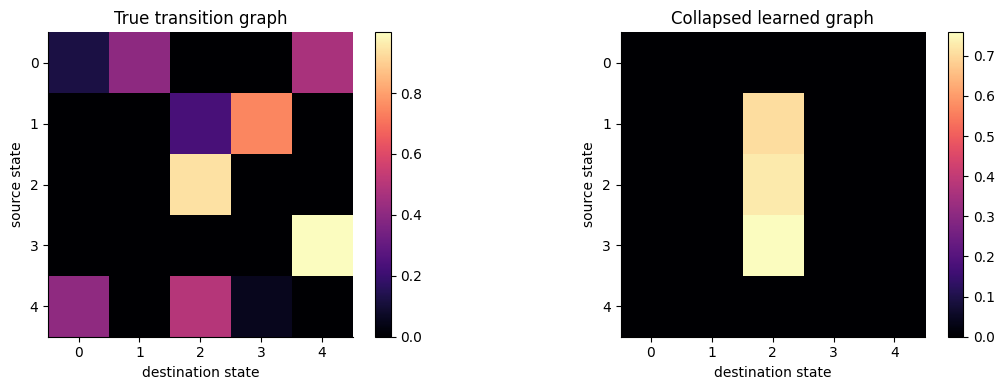

In [12]:
true_adj = nx.to_numpy_array(true_graph, nodelist=list(range(automaton.n_states)), weight="probability")
learned_adj = nx.to_numpy_array(collapsed_graph, nodelist=list(range(automaton.n_states)), weight="probability")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, mat, title in zip(axes, [true_adj, learned_adj], ["True transition graph", "Collapsed learned graph"]):
    im = ax.imshow(mat, cmap="magma", vmin=0.0)
    ax.set_title(title)
    ax.set_xlabel("destination state")
    ax.set_ylabel("source state")
    ax.set_xticks(range(automaton.n_states))
    ax.set_yticks(range(automaton.n_states))
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


## 7. Try Another Run

Useful knobs for visual recovery experiments:

- increase `n_sequences` and sequence `length`,
- train the tiny transformer for more epochs,
- train `BottleneckGraphicalizer` for more epochs,
- set `num_prototypes` near a small multiple of the hidden state count,
- reduce `transition_concentration` to make the true automaton sparser.
